## Tugas Besar Analisis Jejaring Sosial IF-46-DSIS.02
Group 1

Violina Helena Sapan 1301224291

Deshifa Cantika Dondo 1030123330238

Amira Kamila Arvina 10301230061

Elshaday Debora Sambeka 103012330290



In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os

In [ ]:
# ====================================
# LOAD DATASET EDGE LIST
# ====================================
df = pd.read_csv(
    '/content/higgs-retweet_network.edgelist',
    sep=' ',
    header=None,
    names=['source', 'target', 'weight']
)

print("=== DATA AWAL ===")
print(df.head())

print(f"\nJumlah baris awal : {len(df):,}")
print(f"Jumlah kolom           : {df.shape[1]}")
print(f"\nTipe data:")
print(df.dtypes)

=== DATA AWAL ===
   source  target  weight
0  298960  105232       1
1   95688    3393       1
2  353237   62217       1
3    4974    3571       1
4  241892       8       1

Jumlah baris awal : 328,132
Jumlah kolom           : 3

Tipe data:
source    int64
target    int64
weight    int64
dtype: object


# Pre processing data



In [ ]:
# Cek missing value
print(f"\n[Cek Missing Value]")
print(df.isnull().sum())

# Hapus baris yang mengandung missing value (jika ada)
before = len(df)
df = df.dropna()
after = len(df)
print(f"Baris dihapus karena missing value: {before - after}")

# Hapus self-loop (userA == userB)
before = len(df)
df = df[df["source"] != df["target"]]
after = len(df)
print(f"Baris dihapus karena self-loop    : {before - after}")

# Hapus duplikat edge
before = len(df)
df = df.drop_duplicates(subset=["source", "target"])
after = len(df)
print(f"Baris dihapus karena duplikat     : {before - after}")

# Cek weight >= 1
before = len(df)
df = df[df["weight"] >= 1]
after = len(df)
print(f"Baris dihapus karena weight < 1   : {before - after}")

print(f"\nJumlah baris setelah preprocessing: {len(df):,}")




[Cek Missing Value]
source    0
target    0
weight    0
dtype: int64
Baris dihapus karena missing value: 0
Baris dihapus karena self-loop    : 0
Baris dihapus karena duplikat     : 0
Baris dihapus karena weight < 1   : 0

Jumlah baris setelah preprocessing: 328,132


# Struktur Jaringan (node,edge, density, diameter)


In [ ]:
import networkx as nx
G = nx.from_pandas_edgelist(
    df,
    source='source',
    target='target',
    edge_attr='weight',
    create_using=nx.DiGraph()
)

print("=== STRUKTUR JARINGAN ===")

num_nodes = G.number_of_nodes()

num_edges = G.number_of_edges()

density = nx.density(G)

print(f"Jumlah Node   : {num_nodes:,}")
print(f"Jumlah Edge   : {num_edges:,}")
print(f"Density Graph : {density:.6f}")
print(f"Diameter Graph : 19 (dari dataset)")

=== STRUKTUR JARINGAN ===
Jumlah Node   : 256,491
Jumlah Edge   : 328,132
Density Graph : 0.000005
Diameter Graph : 19 (dari dataset)


# Metrik Awal (degree, betweenness, closeness, eigenvector, PageRank, community, diffusion)

In [ ]:
sample_df = df.sample(n=1000, random_state=42)
G_sample = nx.from_pandas_edgelist(
    sample_df,
    source='source',
    target='target',
    edge_attr='weight',
    create_using=nx.DiGraph()
)

In [ ]:
# Degree Centrality
print("=== Degree Centrality ===")
degree_centrality = nx.degree_centrality(G_sample)

degree_df = pd.DataFrame({
    'Node': degree_centrality.keys(),
    'Degree_Centrality': degree_centrality.values()
})

degree_df = degree_df.sort_values(
    by='Degree_Centrality',
    ascending=False
)

print(degree_df.head(10))


=== Degree Centrality ===
      Node  Degree_Centrality
21      88           0.025519
93     677           0.011276
140  14454           0.009496
238    349           0.005935
85    3549           0.005341
31    2567           0.004748
124    138           0.004748
360     15           0.004748
392   7533           0.003561
321  14572           0.003561


In [ ]:
# Betweenness Centrality
print("=== Betweenness Centrality ===")
betweenness = nx.betweenness_centrality(G_sample)

bet_df = pd.DataFrame({
    'Node': betweenness.keys(),
    'Betweenness': betweenness.values()
})

print(
    bet_df.sort_values(
        by='Betweenness',
        ascending=False
    ).head(10)
)

=== Betweenness Centrality ===
        Node   Betweenness
714    68206  3.524179e-07
612   259311  3.524179e-07
358     5071  3.524179e-07
1131  282679  0.000000e+00
1130  194092  0.000000e+00
1129  435308  0.000000e+00
1128   34947  0.000000e+00
1127  260161  0.000000e+00
1126   61161  0.000000e+00
1125  394560  0.000000e+00


In [ ]:
# Closeness Centrality
print("=== Closeness Centrality ===")
closeness = nx.closeness_centrality(G_sample)

close_df = pd.DataFrame({
    'Node': closeness.keys(),
    'Closeness': closeness.values()
})

print(
    close_df.sort_values(
        by='Closeness',
        ascending=False
    ).head(10)
)

=== Closeness Centrality ===
      Node  Closeness
21      88   0.027887
93     677   0.012841
140  14454   0.010335
238    349   0.006890
648    283   0.006264
96    1988   0.005637
87     519   0.003758
124    138   0.003758
392   7533   0.003445
321  14572   0.003445


In [ ]:
# eigenvector Centrality
print("=== eigenvector Centrality ===")
eigenvector = nx.eigenvector_centrality(
    G_sample,
    max_iter=1000
)

eigen_df = pd.DataFrame({
    'Node': eigenvector.keys(),
    'Eigenvector': eigenvector.values()
})

print(
    eigen_df.sort_values(
        by='Eigenvector',
        ascending=False
    ).head(10)
)

=== eigenvector Centrality ===
        Node  Eigenvector
3076   42172     0.677082
21        88     0.403043
1823   22651     0.338906
975     2367     0.169818
1687    1984     0.169818
720    50325     0.169818
3000   79198     0.169818
1510  288730     0.169818
2867  137746     0.169818
2870  255219     0.169818


In [ ]:
# Pagerank
print("=== Pagerank ===")
pagerank = nx.pagerank(G_sample)

pagerank_df = pd.DataFrame({
    'Node': pagerank.keys(),
    'PageRank': pagerank.values()
})

print(
    pagerank_df.sort_values(
        by='PageRank',
        ascending=False
    ).head(10)
)

=== Pagerank ===
      Node  PageRank
21      88  0.015924
93     677  0.007310
140  14454  0.005923
238    349  0.004017
648    283  0.003670
96    1988  0.003237
87     519  0.002284
124    138  0.002284
392   7533  0.002111
321  14572  0.002111


In [ ]:
# COMMUNITY DETECTION
print("=== COMMUNITY DETECTION ===")
from networkx.algorithms.community import louvain_communities

communities = louvain_communities(G_sample)

print("Jumlah community:", len(communities))

=== COMMUNITY DETECTION ===
Jumlah community: 686


In [ ]:
# DIFUSSION (simple spread)
print("=== DIFFUSION ===")


start_node = list(G_sample.nodes())[0]

reachable_nodes = nx.descendants(G_sample, start_node)

print(f"Node awal penyebaran : {start_node}")

print(f"Jumlah node terdifusi : {len(reachable_nodes)}")

print("\nContoh node yang menerima informasi:")
print(list(reachable_nodes)[:10])

=== DIFFUSION ===
Node awal penyebaran : 99782
Jumlah node terdifusi : 1

Contoh node yang menerima informasi:
[1276]


# Visualisasi

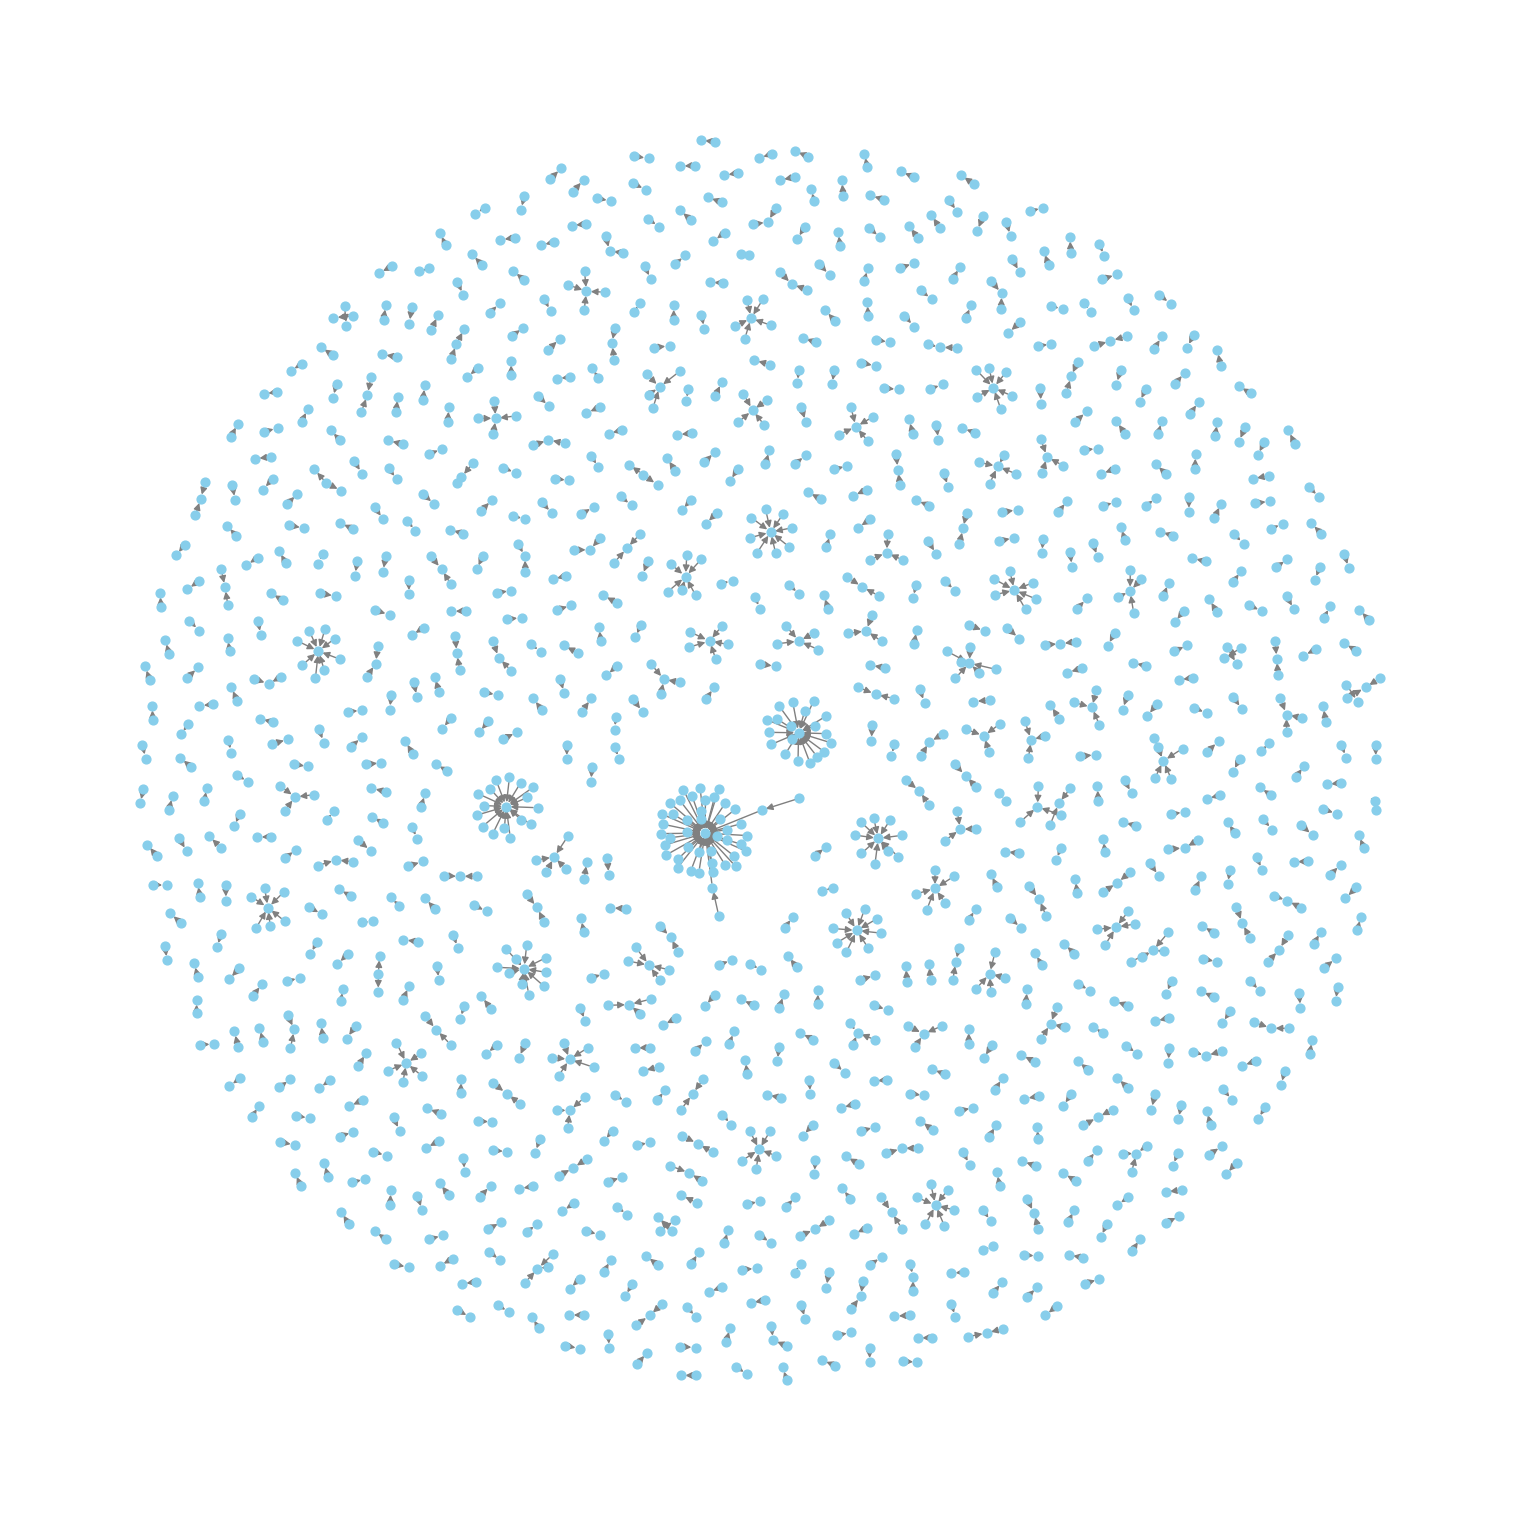

In [ ]:
plt.figure(figsize=(15, 15))

pos = nx.spring_layout(G_sample, k=0.3, seed=42)

nx.draw(
    G_sample,
    pos,
    with_labels=False,
    node_size=40,
    node_color='skyblue',
    edge_color='gray',
)

plt.show()